# 6. Fine tuning LLM

## Two types of fine tuning
- Classification fine tuning - This type does fine tuning of LLM model to make the model classify the data. Example: spam or not spam, sentiment analysis on customer review,etc
- Instruction fine tuning - This type of fine tuning trains the LLM to handle various tasks based on the instruction

## Choosing the right approach

**Classification fine-tuning**
- It is ideal for projects requiring precise categorization of data into predefined classes, such as sentiment analysis or spam detection.
- It requires less data and compute power, but its use is confined to the specific classes on which the model has been trained

**Instruction fine-tuning**
- It improves a model’s ability to understand and generate responses based on specific user instructions.
- It is best suited for models that need to handle a variety of tasks based on complex user instructions, improving flexibility and interaction quality.
- It demands larger datasets and greater computational resources to develop models proficient in various tasks

## Classification fine tuning for spam detection

### 1. Import and split data

In [1]:
import urllib.request
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"


def download_and_unzip_spam_data(
        url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download "
              "and extraction."
        )
        return

    with urllib.request.urlopen(url) as response:    # downloads the file
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())

    with zipfile.ZipFile(zip_path, "r") as zip_ref:    # unzips the file
        zip_ref.extractall(extracted_path)

    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)               # adds .tsv file extension
    print(f"File downloaded and saved as {data_file_path}")

download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

File downloaded and saved as sms_spam_collection/SMSSpamCollection.tsv


In [2]:
import pandas as pd
df = pd.read_csv(
    data_file_path, sep="\t", header=None, names=["Label", "Text"]
)
df.head()

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
print(df["Label"].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


In [4]:
# Create balanced dataset
def create_balanced_dataset(df):
    num_spam = df[df["Label"] == "spam"].shape[0]     # Count the minor class label
    ham_subset = df[df["Label"] == "ham"].sample(
        num_spam, random_state=123
    )                                         # undersample major class label equal to minor class
    balanced_df = pd.concat([
        ham_subset, df[df["Label"] == "spam"]
    ])                               # merge both samples to form undersampled df
    return balanced_df

balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


In [5]:
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})

In [6]:
# Split the dataset
def random_split(df, train_frac, validation_frac):

    df = df.sample(
        frac=1, random_state=123
    ).reset_index(drop=True)               # shuffle the entire dataframe
    train_end = int(len(df) * train_frac)          # keep fraction of df as train
    validation_end = train_end + int(len(df) * validation_frac) # keeping another fraction as validation
    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]

    return train_df, validation_df, test_df

train_df, validation_df, test_df = random_split(
    balanced_df, 0.7, 0.1)                     # split dataset into train, val, test dataset

In [7]:
train_df.to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)

### 2. Create Pytorch datasets

- To batch these messages as we did with the text chunks, we have two primary options:

  1. Truncate all messages to the length of the shortest message in the dataset or batch.
  2. Pad all messages to the length of the longest message in the dataset or batch.

The first option is computationally cheaper, but it may result in significant information loss if shorter messages are much smaller than the average or longest messages, potentially reducing model performance. So, we opt for the second option, which preserves the entire content of all messages.

To implement batching, where all messages are padded to the length of the longest message in the dataset, we add padding tokens to all shorter messages. For this purpose, we use "<|endoftext|>" as a padding token.

In [8]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


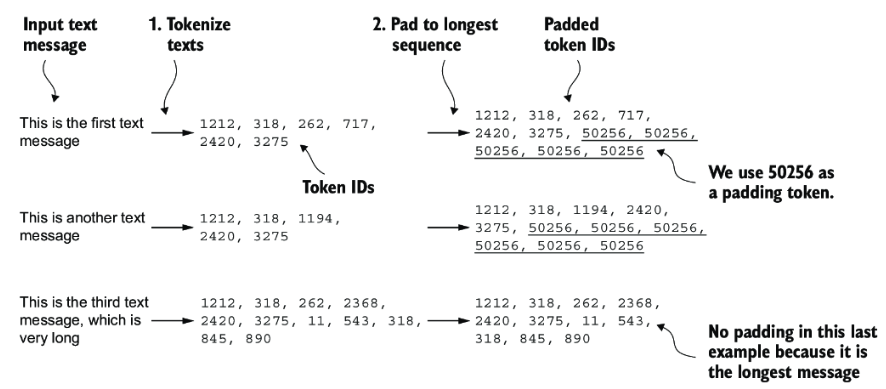

In [9]:
import torch
from torch.utils.data import Dataset

class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None,
                 pad_token_id=50256):
        self.data = pd.read_csv(csv_file)
        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data["Text"]
        ]

        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            # Truncates sequences if they are longer than max_length
            self.max_length = max_length
            self.encoded_texts = [
                encoded_text[:self.max_length]
                for encoded_text in self.encoded_texts
            ] # pads the sequence to longest sequence
        self.encoded_texts = [
            encoded_text + [pad_token_id] *
            (self.max_length - len(encoded_text))
            for encoded_text in self.encoded_texts
        ]

    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )

    def __len__(self):
        return len(self.data)

    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:
            encoded_length = len(encoded_text)
            if encoded_length > max_length:
                max_length = encoded_length
        return max_length

In [10]:
train_dataset = SpamDataset(
    csv_file="train.csv",
    max_length=None,
    tokenizer=tokenizer
)

print(train_dataset.max_length)

120


Next, we pad the validation and test sets to match the length of the longest training sequence. Importantly, any validation and test set samples exceeding the length of the longest training example are truncated using encoded_text[:self.max_length] in the SpamDataset code we defined earlier. This truncation is optional; you can set max_length=None for both validation and test sets, provided there are no sequences exceeding 1,024 tokens in these sets:

In [11]:
val_dataset = SpamDataset(
    csv_file="validation.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)
test_dataset = SpamDataset(
    csv_file="test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

### 3. Create Pytorch DataLoaders

In [12]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8
torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)
val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

In [13]:
for input_batch, target_batch in train_loader:
    pass
print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

Input batch dimensions: torch.Size([8, 120])
Label batch dimensions torch.Size([8])
130 training batches
19 validation batches
38 test batches


### 4. Initialising model with pretrained weights

In [14]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"
BASE_CONFIG = {
    "vocab_size": 50257,
    "context_length": 1024,
    "drop_rate": 0.0,
    "qkv_bias": True
}
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

In [15]:
import torch
from torch import nn

class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out,
                 context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads    # Reduces the projection dim to match the desired output dim
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)    # Uses a Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length),
                       diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        keys = self.W_key(x)         # shape = b, num_tokens, d_out
        queries = self.W_query(x)    # shape = b, num_tokens, d_out
        values = self.W_value(x)     # shape = b, num_tokens, d_out

        #implicitly split the matrix by adding a num_heads dimension.
        # Then we unroll the last dim: (b, num_tokens, d_out) -&gt; (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transposes from shape (b, num_tokens, num_heads, head_dim) to (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        attn_scores = queries @ keys.transpose(2, 3)   # computes dot product for each head
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]    # mask truncated to num of tokens

        attn_scores.masked_fill_(mask_bool, -torch.inf)     # uses the mask to fill attention scores

        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vec = (attn_weights @ values).transpose(1, 2)   # Combines heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(
            b, num_tokens, self.d_out
        )
        context_vec = self.out_proj(context_vec)    # adds an optional linear projection
        return context_vec

In [16]:
# Implementation of LayerNorm class
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        #unbiased = False will consider all n and not n-1 to calculate variance (Bessel's correction)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

In [17]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))

In [18]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]), # the input size is expanded to higher dimension
            GELU(), # activation of GeLU
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]), # Bring it back to original size
        )

    def forward(self, x):
        return self.layers(x)

In [19]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        shortcut = x #shortcut connection for attention block
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut      # add original input back

        shortcut = x         # Shortcut connection for feed forward block
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut      # Adds the original input back
        return x

In [20]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device) # device setting either CPU or GPU
        )
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [21]:
import numpy as np

def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, "
                          "Right: {right.shape}"
        )
    return torch.nn.Parameter(torch.tensor(right))

# Sets the model’s positional and token embedding weights to those specified in params.
def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])

    for b in range(len(params["blocks"])):     # iterates over each transformer block in the model
        #The np.split function is used to divide the attention and bias weights into
        #three equal parts for the query, key, and value components.
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale,
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift,
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale,
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift,
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    # The original GPT-2 model by OpenAI reused the token embedding weights in the output layer
    #to reduce the total number of parameters, which is a concept known as weight tying.
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])

In [22]:
!pip install tensorflow>=2.15.0  tqdm>=4.66

In [23]:
import urllib.request
url = (
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/main/ch05/"
    "01_main-chapter-code/gpt_download.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('gpt_download.py', <http.client.HTTPMessage at 0x7a7841f5e510>)

In [24]:
from gpt_download import download_and_load_gpt2

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
    model_size=model_size, models_dir="gpt2"
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 225kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 3.03MiB/s]
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 278kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [00:47<00:00, 10.5MiB/s]
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 12.3MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:00<00:00, 1.95MiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 1.89MiB/s]


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [25]:
def generate_text_simple(model,
                         idx,                 # idx is array of (batch_size, num_tokens) in current context
                         max_new_tokens,
                         context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]    # crops current context if it exceeds supported context size
        with torch.no_grad():
            logits = model(idx_cond)

        # Focuses only on the last time step, so that (batch, n_token, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]
        probas = torch.softmax(logits, dim=-1)           # probas has shape (batch_size, vocab_size)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)    # shape (batch_size, 1)
        # Appends sampled index to the running sequence, where idx has shape (batch, n_tokens+1)
        idx = torch.cat((idx, idx_next), dim=1)

    return idx

In [26]:
import tiktoken

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)    # .unsqueeze(0) adds the batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)                # Removes batch dimension
    return tokenizer.decode(flat.tolist())

In [27]:
text_1 = "Every effort moves you"
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_1, tokenizer),
    max_new_tokens=15,
    context_size=BASE_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work


In [28]:
text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_2, tokenizer),
    max_new_tokens=23,
    context_size=BASE_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner


- Based on the output, it’s apparent that the model is struggling to follow instructions. This result is expected, as it has only undergone pretraining and lacks instruction fine-tuning. So, let’s prepare the model for classification fine-tuning.

### 5. Adding a classification head

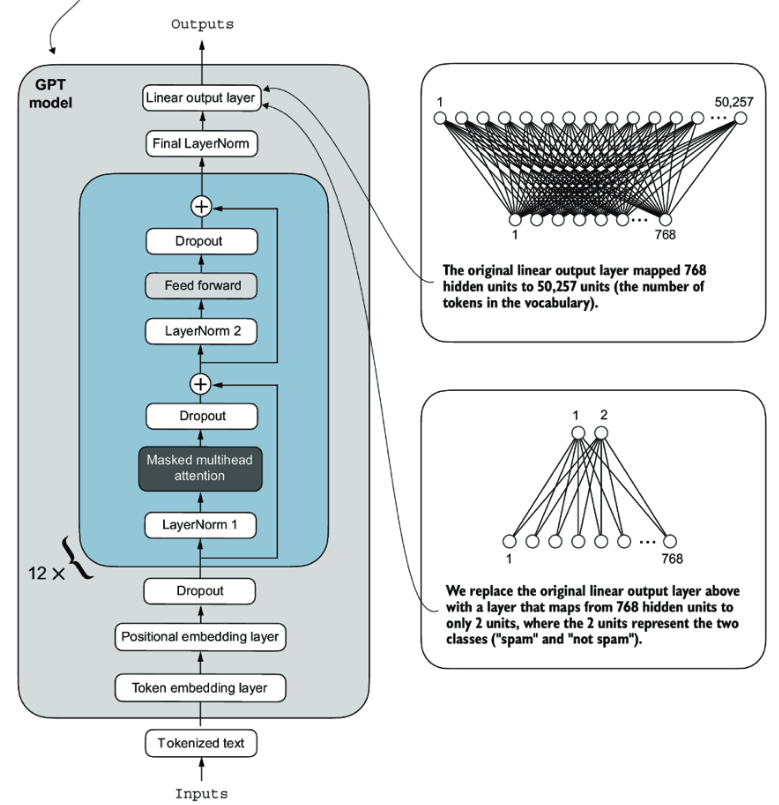

**Fine tuning selected layers vs all layers**

- Since we start with a pretrained model, it’s not necessary to fine-tune all model layers.
- In neural network-based language models, the lower layers generally capture basic language structures and semantics applicable across a wide range of tasks and datasets.
- So, fine-tuning only the last layers (i.e., layers near the output), which are more specific to nuanced linguistic patterns and task-specific features, is often sufficient to adapt the model to new tasks.
- A nice side effect is that it is computationally more efficient to fine-tune only a small number of layers.

In [29]:
# Freeze the weights of the model and make it non trainable
for param in model.parameters():
    param.requires_grad = False

In [30]:
# Modify the output layer from existing dimension (768, 50257) to (768,2)
print("Current output layer",model.out_head)
torch.manual_seed(123)
num_classes = 2
model.out_head = torch.nn.Linear(
    in_features=BASE_CONFIG["emb_dim"],
    out_features=num_classes
)
print("Modified output layer",model.out_head)

Current output layer Linear(in_features=768, out_features=50257, bias=False)
Modified output layer Linear(in_features=768, out_features=2, bias=True)


- Technically, training the output layer we just added is sufficient. However, as I found in experiments, fine-tuning additional layers can noticeably improve the predictive performance of the model.
- So we will make the final LayerNorm and last transformer block trainable, we set their respective requires_grad to True:

In [31]:
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True
for param in model.final_norm.parameters():
    param.requires_grad = True

In [32]:
# Check the output of the model with an example
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
print("Inputs:", inputs)
print("Inputs dimensions:", inputs.shape) # (batch_size, num_tokens)

Inputs: tensor([[5211,  345,  423,  640]])
Inputs dimensions: torch.Size([1, 4])


In [33]:
with torch.no_grad():
    outputs = model(inputs)
print("Outputs:\n", outputs)
print("Outputs dimensions:", outputs.shape) # (batch_size, num_tokens, output)

Outputs:
 tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]])
Outputs dimensions: torch.Size([1, 4, 2])


In [34]:
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-3.5983,  3.9902]])


- Let’s understand why we are particularly interested in the last output token only. We have already explored the attention mechanism, which establishes a relationship between each input token and every other input token, and the concept of a causal attention mask, commonly used in GPT-like models (see chapter 3). This mask restricts a token’s focus to its current position and the those before it, ensuring that each token can only be influenced by itself and the preceding tokens.
- Given this causal attention mask setup, the last token in a sequence accumulates the most information since it is the only token with access to data from all the previous tokens. Therefore, in our spam classification task, we focus on this last token during the fine-tuning process.

### 6. Calculating the classification loss and accuracy

In [35]:
# Obtaining prediction class label
probas = torch.softmax(outputs[:, -1, :], dim=-1)
label = torch.argmax(probas)
print("Class label:", label.item()) # if 1 then class is "spam", 0 is "ham"

Class label: 1


In [36]:
logits = outputs[:, -1, :]
label = torch.argmax(logits)
print("Class label:", label.item())

Class label: 1


In [37]:
# calculate accuracy
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0, 0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch = input_batch.to(device)
            target_batch = target_batch.to(device)


            with torch.no_grad():
                logits = model(input_batch)[:, -1, :]     #1
            predicted_labels = torch.argmax(logits, dim=-1)

            num_examples += predicted_labels.shape[0]
            correct_predictions += (
                (predicted_labels == target_batch).sum().item()
            )

        else:
            break
    return correct_predictions / num_examples

In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

torch.manual_seed(123)
train_accuracy = calc_accuracy_loader(
    train_loader, model, device, num_batches=10
)
val_accuracy = calc_accuracy_loader(
    val_loader, model, device, num_batches=10
)
test_accuracy = calc_accuracy_loader(
    test_loader, model, device, num_batches=10
)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 46.25%
Validation accuracy: 45.00%
Test accuracy: 48.75%


In [39]:
# Use cross entropy loss as proxy for maximizing accuracy, as accuracy metric is not differentiable

# Calculate loss for one batch
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)[:, -1, :]     #1
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss

# calculate loss for all batches from dataloader
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:                                        #1
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In [40]:
# Calculates initiall loss for each dataset
with torch.no_grad():
    train_loss = calc_loss_loader(
        train_loader, model, device, num_batches=5
    )
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)
print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 2.453
Validation loss: 2.583
Test loss: 2.322


### 7. Fine tuning the model

In [41]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        )
    model.train()
    return train_loss, val_loss

In [42]:
def train_classifier_simple(
        model, train_loader, val_loader, optimizer, device,
        num_epochs, eval_freq, eval_iter):
    #Initialize lists to track losses and examples seen
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            loss.backward()
            optimizer.step()
            examples_seen += input_batch.shape[0]
            global_step += 1
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}"
                )
        train_accuracy = calc_accuracy_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_accuracy = calc_accuracy_loader(
            val_loader, model, device, num_batches=eval_iter
        )

        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen

In [43]:
import time

start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs = 5


train_losses, val_losses, train_accs, val_accs, examples_seen = \
    train_classifier_simple(
        model, train_loader, val_loader, optimizer, device,
        num_epochs=num_epochs, eval_freq=50,
        eval_iter=5
    )

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.153, Val loss 2.392
Ep 1 (Step 000050): Train loss 0.617, Val loss 0.637
Ep 1 (Step 000100): Train loss 0.523, Val loss 0.557
Training accuracy: 70.00% | Validation accuracy: 72.50%
Ep 2 (Step 000150): Train loss 0.561, Val loss 0.489
Ep 2 (Step 000200): Train loss 0.419, Val loss 0.397
Ep 2 (Step 000250): Train loss 0.409, Val loss 0.353
Training accuracy: 82.50% | Validation accuracy: 85.00%
Ep 3 (Step 000300): Train loss 0.333, Val loss 0.320
Ep 3 (Step 000350): Train loss 0.340, Val loss 0.306
Training accuracy: 90.00% | Validation accuracy: 90.00%
Ep 4 (Step 000400): Train loss 0.136, Val loss 0.200
Ep 4 (Step 000450): Train loss 0.153, Val loss 0.132
Ep 4 (Step 000500): Train loss 0.222, Val loss 0.137
Training accuracy: 100.00% | Validation accuracy: 97.50%
Ep 5 (Step 000550): Train loss 0.207, Val loss 0.143
Ep 5 (Step 000600): Train loss 0.083, Val loss 0.074
Training accuracy: 100.00% | Validation accuracy: 97.50%
Training completed in 1.10 mi

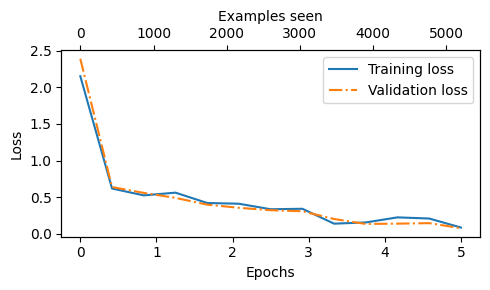

In [44]:
import matplotlib.pyplot as plt

def plot_values(
        epochs_seen, examples_seen, train_values, val_values,
        label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(
        epochs_seen, val_values, linestyle="-.",
        label=f"Validation {label}"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    ax2 = ax1.twiny()
    ax2.plot(examples_seen, train_values, alpha=0)
    ax2.set_xlabel("Examples seen")

    fig.tight_layout()
    plt.savefig(f"{label}-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

**Choosing number of Epochs**

Earlier, when we initiated the training, we set the number of epochs to five. The number of epochs depends on the dataset and the task’s difficulty, and there is no universal solution or recommendation, although an epoch number of five is usually a good starting point. If the model overfits after the first few epochs as a loss plot (see figure 6.16), you may need to reduce the number of epochs. Conversely, if the trendline suggests that the validation loss could improve with further training, you should increase the number of epochs. In this concrete case, five epochs is a reasonable number as there are no signs of early overfitting, and the validation loss is close to 0.

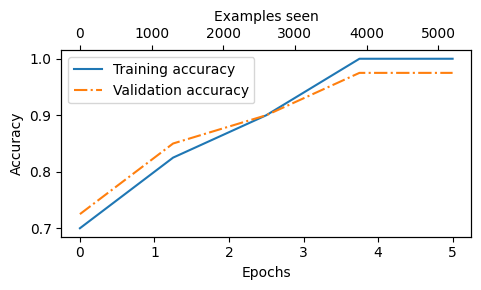

In [45]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))

plot_values(
    epochs_tensor, examples_seen_tensor, train_accs, val_accs,
    label="accuracy"
)

In [46]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 97.21%
Validation accuracy: 97.32%
Test accuracy: 95.67%


### 8. LLM as spam classifier

In [47]:
def classify_review(
        text, model, tokenizer, device, max_length=None,
        pad_token_id=50256):
    model.eval()

    input_ids = tokenizer.encode(text)          # Prepares inputs to the model
    supported_context_length = model.pos_emb.weight.shape[0]

    input_ids = input_ids[:min(              # truncates seq if they are too long
        max_length, supported_context_length
    )]

    input_ids += [pad_token_id] * (max_length - len(input_ids))    # pads sequence to longest seq

    input_tensor = torch.tensor(
        input_ids, device=device
    ).unsqueeze(0)              # adds batch dimension

    with torch.no_grad():                                # model inference without gradient tracking
        logits = model(input_tensor)[:, -1, :]     # logits of last token
    predicted_label = torch.argmax(logits, dim=-1).item()

    return "spam" if predicted_label == 1 else "not spam"

In [48]:
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)

print(classify_review(
    text_1, model, tokenizer, device, max_length=train_dataset.max_length
))

spam


In [49]:
text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

print(classify_review(
    text_2, model, tokenizer, device, max_length=train_dataset.max_length
))

not spam


In [50]:
# Save the model
torch.save(model.state_dict(), "review_classifier.pth")

In [51]:
# To reload the model
model_state_dict = torch.load("review_classifier.pth", map_location=device)
model.load_state_dict(model_state_dict)

<All keys matched successfully>

### Summary

- There are different strategies for fine-tuning LLMs, including classification fine-tuning and instruction fine-tuning.
- Classification fine-tuning involves replacing the output layer of an LLM via a small classification layer.
- In the case of classifying text messages as “spam” or “not spam,” the new classification layer consists of only two output nodes. Previously, we used the number of output nodes equal to the number of unique tokens in the vocabulary (i.e., 50,256).
- Instead of predicting the next token in the text as in pretraining, classification fine-tuning trains the model to output a correct class label—for example, “spam” or “not spam.”
- The model input for fine-tuning is text converted into token IDs, similar to pretraining.
- Before fine-tuning an LLM, we load the pretrained model as a base model.
Evaluating a classification model involves calculating the classification accuracy (the fraction or percentage of correct predictions).
- Fine-tuning a classification model uses the same cross entropy loss function as when pretraining the LLM.

# 7. Fine tuning to follow instructions

### Introduction to Instruction fine tuning
- Instruction fine-tuning is one of the main techniques behind developing LLMs for chatbot applications, personal assistants, and other conversational tasks.
- pretrained LLMs often struggle with specific instructions, such as “Fix the grammar in this text” or “Convert this text into passive voice.”
- Preparing a dataset is key for instruction fine tuning

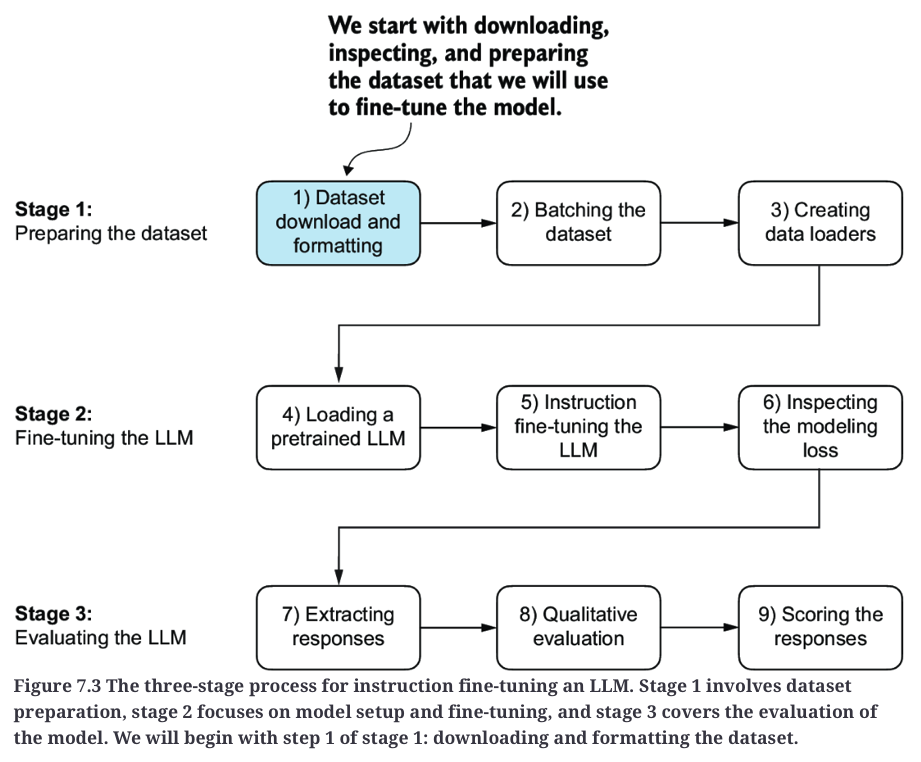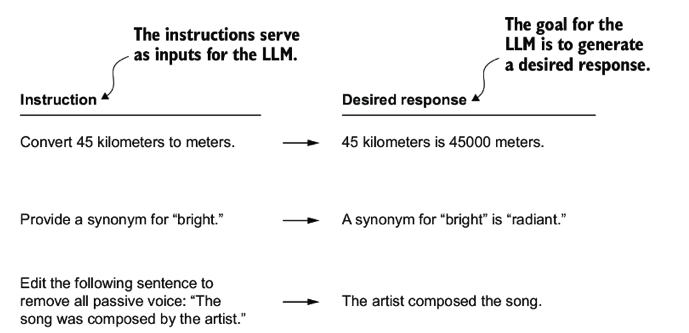

### 2. Preparing dataset for instruction fine tuning

In [52]:
import json
import os
import urllib.request

def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        with urllib.request.urlopen(url) as response:
            text_data = response.read().decode("utf-8")
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)

    with open(file_path, "r") as file:
        data = json.load(file)
    return data

file_path = "instruction-data.json"
url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)


data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))

Number of entries: 1100


In [53]:
print("Example entry:\n", data[50])
print("Another example entry:\n", data[999])

Example entry:
 {'instruction': 'Identify the correct spelling of the following word.', 'input': 'Ocassion', 'output': "The correct spelling is 'Occasion.'"}
Another example entry:
 {'instruction': "What is an antonym of 'complicated'?", 'input': '', 'output': "An antonym of 'complicated' is 'simple'."}


- Instruction fine tuning creates both input-output pair to be given to model for fine tuning
- Generally, the pairs are generated based on certain prompting styles like `Alpaca` or `phi-3`. Alpaca is most widely used one.

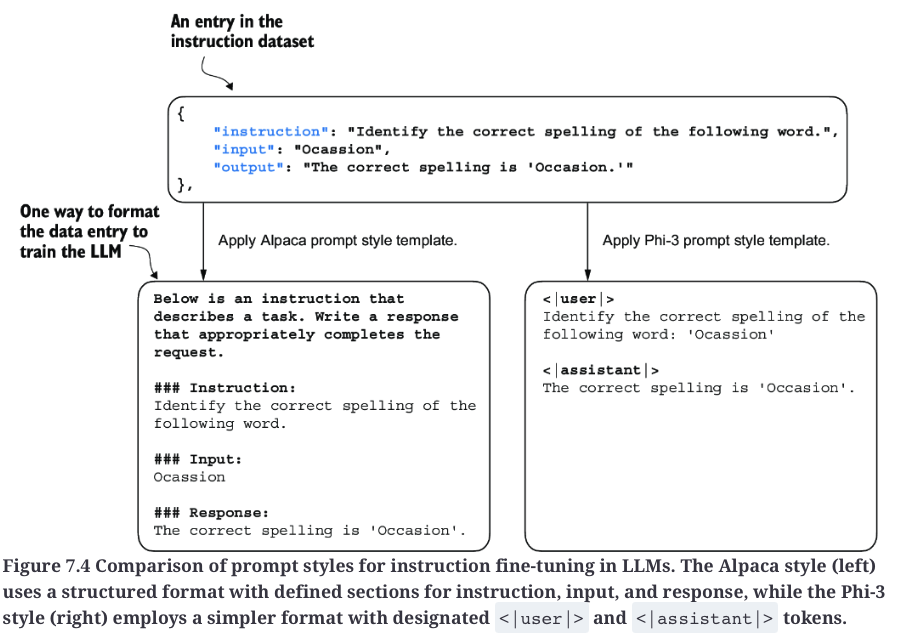

In [54]:
# Format input from JSON to Alpaca file format
def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = (
        f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
    )
    return instruction_text + input_text

In [55]:
model_input = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]['output']}"
print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


- Note that the format_input skips the optional ### Input: section if the 'input' field is empty,

In [56]:
model_input = format_input(data[999])
desired_response = f"\n\n### Response:\n{data[999]['output']}"
print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.


In [57]:
# partitioning dataset
train_portion = int(len(data) * 0.85)
test_portion = int(len(data) * 0.1)
val_portion = len(data) - train_portion - test_portion

train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]

print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 935
Validation set length: 55
Test set length: 110


### 3. Organizing data into training batches

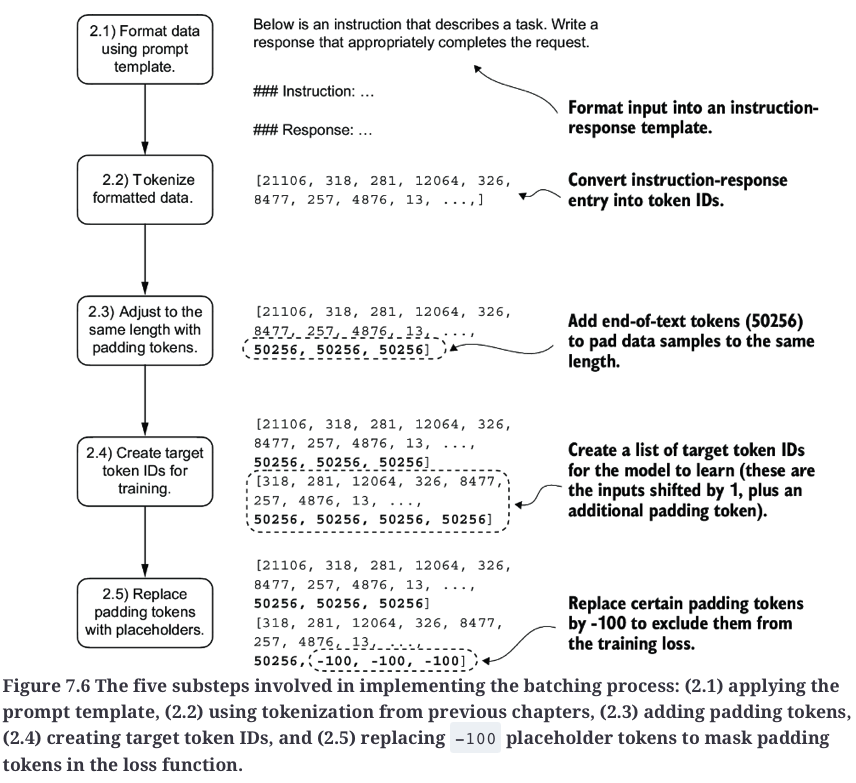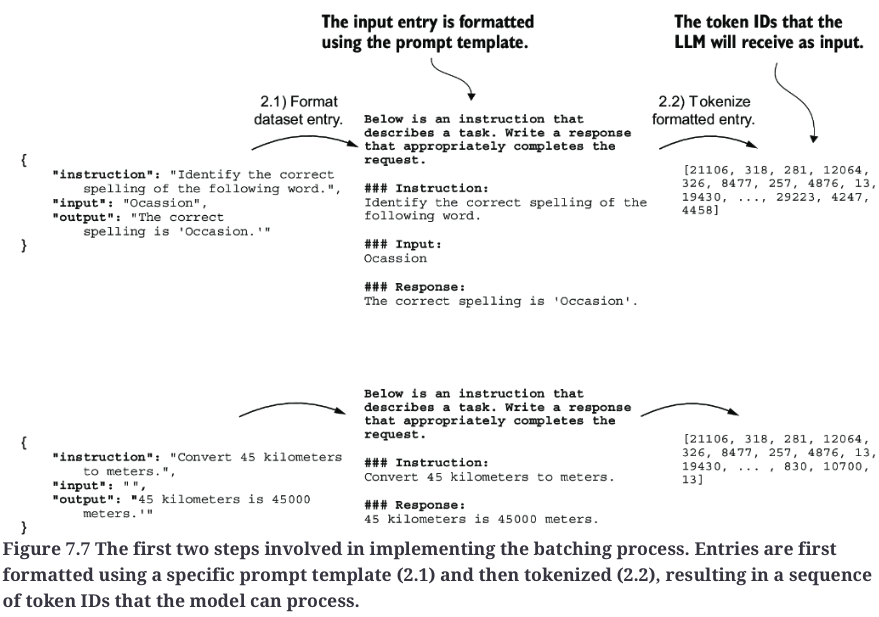

In [58]:
import torch
from torch.utils.data import Dataset

class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data
        self.encoded_texts = []
        for entry in data:
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = instruction_plus_input + response_text
            self.encoded_texts.append(
                tokenizer.encode(full_text)
            )

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)

- Create a custom collate function pads the training examples in each batch to the same length while allowing different batches to have different lengths. This approach minimizes unnecessary padding by only extending sequences to match the longest one in each batch, not the whole dataset.

In [59]:
def custom_collate_draft_1(
    batch,
    pad_token_id=50256,
    device="cpu"
):
    batch_max_length = max(len(item)+1 for item in batch)   # finds the longest sequence in batch
    inputs_lst = []

    for item in batch:     # pads and prepares input
        new_item = item.copy()
        new_item += [pad_token_id]


        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])    # removes extra padded token added earlier
        inputs_lst.append(inputs)

    # converts list of inputs to a tensor and transfers it to target device
    inputs_tensor = torch.stack(inputs_lst).to(device)
    return inputs_tensor

In [60]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]
batch = (
    inputs_1,
    inputs_2,
    inputs_3
)
print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


- we also need to create batches with the target token IDs corresponding to the batch of input IDs.
- These target IDs are crucial because they represent what we want the model to generate and what we need during training to calculate the loss for the weight updates.
- That is, we modify our custom collate function to return the target token IDs in addition to the input token IDs.
- For each input sequence, the corresponding target sequence is created by shifting the token IDs one position to the right, omitting the first token of the input, and appending an end-of-text token.

In [61]:
def custom_collate_draft_2(
    batch,
    pad_token_id=50256,
    device="cpu"
):
    batch_max_length = max(len(item)+1 for item in batch)
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]

        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])     # Truncates the last token for inputs
        targets = torch.tensor(padded[1:])    # Shifts +1 to the right for targets
        inputs_lst.append(inputs)
        targets_lst.append(targets)

    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

inputs, targets = custom_collate_draft_2(batch)
print("Input:\n",inputs)
print("Output:\n",targets)

Input:
 tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
Output:
 tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]])


- We assign `-100` value for padding token to not participate in loss calculation during training
- This special value allows us to exclude these padding tokens from contributing to the training loss calculation, ensuring that only meaningful data influences model learning.

In [62]:
def custom_collate_fn(
    batch,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=None,
    device="cpu"
):
    batch_max_length = max(len(item)+1 for item in batch)
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]

        # Pads sequences to max_length
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])      # Truncates the last token for inputs
        targets = torch.tensor(padded[1:])     # Shifts +1 to the right for targets

        # Replaces all but the first padding tokens in targets by ignore_index
        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        if allowed_max_length is not None:
            # Optionally truncates to the maximum sequence length
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor


In [63]:
inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


- Shi et al., “Instruction Tuning With Loss Over Instructions” (https://arxiv.org/abs/2405.14394)

### 4. Creating data loaders

In [64]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# if torch.backends.mps.is_available():   #1
#     device = torch.device("mps")"
print("Device:", device)

Device: cuda


- To reuse the chosen device setting in custom_collate_fn when we plug it into the PyTorch DataLoader class, we use the partial function from Python’s functools standard library to create a new version of the function with the device argument prefilled

In [65]:
from functools import partial

customized_collate_fn = partial(
    custom_collate_fn,
    device=device,
    allowed_max_length=1024
)

In [66]:
from torch.utils.data import DataLoader
import tiktoken

num_workers = 0
batch_size = 8

torch.manual_seed(123)
tokenizer = tiktoken.get_encoding("gpt2")


train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)

val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

In [67]:
print("Train loader:")
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)

Train loader:
torch.Size([8, 61]) torch.Size([8, 61])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 75]) torch.Size([8, 75])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 79]) torch.Size([8, 79])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 83]) torch.Size([8, 83])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 68]) torch.

### 5. Load pretraining model

- We load the medium-sized model with `355 million parameters`. The reason for this choice is that the `124-million-parameter` model is too limited in capacity to achieve satisfactory results via instruction fine-tuning. Specifically, smaller models lack the necessary capacity to learn and retain the intricate patterns and nuanced behaviors required for high-quality instruction-following tasks.

In [68]:
BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

CHOOSE_MODEL = "gpt2-medium (355M)"
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")

settings, params = download_and_load_gpt2(
    model_size=model_size,
    models_dir="gpt2"
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 168kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 2.93MiB/s]
hparams.json: 100%|██████████| 91.0/91.0 [00:00<00:00, 201kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 1.42G/1.42G [01:48<00:00, 13.1MiB/s]
model.ckpt.index: 100%|██████████| 10.4k/10.4k [00:00<00:00, 18.4MiB/s]
model.ckpt.meta: 100%|██████████| 927k/927k [00:00<00:00, 2.78MiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 1.59MiB/s]


- Take an example input and see how the model gives output with pretrained model weights. This gives an idea of how finetuning helps

In [82]:
torch.manual_seed(123)
input_text = format_input(val_data[0])
print(input_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


In [83]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))
    model.train()

In [84]:
def train_model_simple(model, train_loader, val_loader,
                       optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []    # Initializes list to track progress during training
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):    # starts main training loop
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()   #Resets loss gradients from the previous batch iteration
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            loss.backward()                     # calculates loss gradients
            optimizer.step()                    # updates model weights
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:    # evalution step
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}"
                )

        generate_and_print_sample(                      # prints sample text after each epoch
            model, tokenizer, device, start_context
        )
    return train_losses, val_losses, track_tokens_seen

In [85]:
def generate(model, idx, max_new_tokens, context_size,
             temperature=0.0, top_k=None, eos_id=None):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]
        if top_k is not None:                #filter logits with top k sampling
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(
                logits < min_val,
                torch.tensor(float('-inf')).to(logits.device),
                logits
            )
        if temperature > 0.0:                  # applies temperature scaling
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:    # does greedy next token selection when temperature scaling is disabled
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)
        if idx_next == eos_id:              # stops generating early if EOS is reached
            break
        idx = torch.cat((idx, idx_next), dim=1)
    return idx

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)    # .unsqueeze(0) adds the batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)                # Removes batch dimension
    return tokenizer.decode(flat.tolist())

In [86]:
token_ids = generate(
    model=model,
    idx=text_to_token_ids(input_text, tokenizer),
    max_new_tokens=35,
    context_size=BASE_CONFIG["context_length"],
    eos_id=50256,
)
generated_text = token_ids_to_text(token_ids, tokenizer)

- Above generate() function gives both input and output combined. When evaluating the model performance, we want to focus only on model output. Below code excludes the input text

In [87]:
response_text = generated_text[len(input_text):].strip()
print(response_text)

### Response:

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


This output shows that the pretrained model is not yet capable of correctly following the given instruction. While it does create a Response section, it simply repeats the original input sentence and part of the instruction, failing to convert the active sentence to passive voice as requested. We need to finetune the model weights based on instruction dataset.

### 8. Fine tuning LLM on instruction data

In [90]:
# Use cross entropy loss as proxy for maximizing accuracy, as accuracy metric is not differentiable

# Calculate loss for one batch
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)

    # In instruction fine-tuning, the model outputs logits for each token in the sequence
    # The shape of logits from model(input_batch) will be (batch_size, seq_len, vocab_size)
    logits = model(input_batch)  # No [:, -1, :] here, as we need all token logits

    # Reshape logits and targets for cross_entropy
    # logits: (batch_size * seq_len, vocab_size)
    # targets: (batch_size * seq_len)
    loss = torch.nn.functional.cross_entropy(
        logits.view(-1, logits.size(-1)), # Flatten logits to (N, C) where N=batch_size*seq_len, C=vocab_size
        target_batch.view(-1),          # Flatten targets to (N)
        ignore_index=-100               # This ensures padding tokens don't contribute to loss
    )
    return loss

# calculate loss for all batches from dataloader
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:                                        #1
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In [91]:
# Initial loss for train and validation dataset
model.to(device)
torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(
        train_loader, model, device, num_batches=5
    )
    val_loss = calc_loss_loader(
        val_loader, model, device, num_batches=5
)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 3.82590913772583
Validation loss: 3.7619335651397705


In [92]:
import time

start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=0.00005, weight_decay=0.1
)
num_epochs = 2

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_input(val_data[0]), tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.637, Val loss 2.626
Ep 1 (Step 000005): Train loss 1.174, Val loss 1.103
Ep 1 (Step 000010): Train loss 0.872, Val loss 0.944
Ep 1 (Step 000015): Train loss 0.857, Val loss 0.906
Ep 1 (Step 000020): Train loss 0.776, Val loss 0.881
Ep 1 (Step 000025): Train loss 0.754, Val loss 0.859
Ep 1 (Step 000030): Train loss 0.799, Val loss 0.836
Ep 1 (Step 000035): Train loss 0.714, Val loss 0.808
Ep 1 (Step 000040): Train loss 0.672, Val loss 0.806
Ep 1 (Step 000045): Train loss 0.633, Val loss 0.789
Ep 1 (Step 000050): Train loss 0.663, Val loss 0.783
Ep 1 (Step 000055): Train loss 0.760, Val loss 0.763
Ep 1 (Step 000060): Train loss 0.719, Val loss 0.743
Ep 1 (Step 000065): Train loss 0.653, Val loss 0.735
Ep 1 (Step 000070): Train loss 0.533, Val loss 0.729
Ep 1 (Step 000075): Train loss 0.568, Val loss 0.729
Ep 1 (Step 000080): Train loss 0.604, Val loss 0.725
Ep 1 (Step 000085): Train loss 0.509, Val loss 0.710
Ep 1 (Step 000090): Train loss 0.563, Val loss

In [93]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(
        epochs_seen, val_losses, linestyle="-.", label="Validation loss"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()                   # creates a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)     #invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

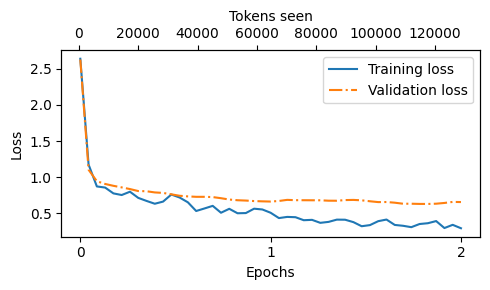

In [94]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

### EXERCISE 7.3 FINE-TUNING ON THE ORIGINAL ALPACA DATASET

The Alpaca dataset, by researchers at Stanford, is one of the earliest and most popular openly shared instruction datasets, consisting of 52,002 entries. As an alternative to the instruction-data.json file we use here, consider fine-tuning an LLM on this dataset. The dataset is available at https://mng.bz/NBnE.

This dataset contains 52,002 entries, which is approximately 50 times more than those we used here, and most entries are longer. Thus, I highly recommend using a GPU to conduct the training, which will accelerate the fine-tuning process. If you encounter out-of-memory errors, consider reducing the batch_size from 8 to 4, 2, or even 1. Lowering the allowed_max_length from 1,024 to 512 or 256 can also help manage memory problems.

### 7. Extracting and saving responses

In [95]:
torch.manual_seed(123)

for entry in test_data[:3]:      # iterates over first 3 samples
    input_text = format_input(entry)
    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)

    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
    )
    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text.strip()}")
    print("-------------------------------------")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a bullet.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

Correct response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> The type of cloud associated with thunderstorms is a cumulus cloud.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejudice'.

Correct response:
>> Jane Austen.

Model response:
>> The author of 'Pride and Prej

Most importantly, model evaluation is not as straightforward as it is for classification fine-tuning, where we simply calculate the percentage of correct spam/non-spam class labels to obtain the classification’s accuracy. In practice, instruction-fine-tuned LLMs such as chatbots are evaluated via multiple approaches:

1. Short-answer and multiple-choice benchmarks, such as Measuring Massive Multitask Language Understanding (MMLU; https://arxiv.org/abs/2009.03300), which test the general knowledge of a model.
2. Human preference comparison to other LLMs, such as LMSYS chatbot arena (https://lmsys.org).
3. Automated conversational benchmarks, where another LLM like GPT-4 is used to evaluate the responses, such as AlpacaEval (https://tatsu-lab.github.io/alpaca_eval/).

In [96]:
# Evaluation using another LLM - an approach inspired from AlpacaEval
# Save test data response from trained model in separate JSON file

from tqdm import tqdm

for i, entry in tqdm(enumerate(test_data), total=len(test_data)):
    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)

    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
    )
    test_data[i]["model_response"] = response_text

with open("instruction-data-with-response.json", "w") as file:
    json.dump(test_data, file, indent=4)         #1

100%|██████████| 110/110 [01:17<00:00,  1.43it/s]


In [97]:
print(test_data[0])

{'instruction': 'Rewrite the sentence using a simile.', 'input': 'The car is very fast.', 'output': 'The car is as fast as lightning.', 'model_response': 'The car is as fast as a bullet.'}


In [98]:
# Save the model
import re

file_name = f"{re.sub(r'[ ()]', '', CHOOSE_MODEL) }-sft.pth"      #1
torch.save(model.state_dict(), file_name)
print(f"Model saved as {file_name}")

# To load the model - model.load_state_dict(torch.load("gpt2 -medium355M-sft.pth"))

Model saved as gpt2-medium355M-sft.pth


### 9. Evaluating fine tuned model

- Previously, we judged the performance of an instruction-fine-tuned model by looking at its responses on three examples of the test set. While this gives us a rough idea of how well the model performs, this method does not scale well to larger amounts of responses. So, we implement a method to automate the response evaluation of the fine-tuned LLM using another, larger LLM
- To evaluate test set responses in an automated fashion, we utilize an existing instruction-fine-tuned 8-billion-parameter Llama 3 model developed by Meta AI. This model can be run locally using the open source Ollama application (https://ollama.com).

In [99]:
import json
from tqdm import tqdm

file_path = "instruction-data-with-response.json"
with open(file_path, "r") as file:
    test_data = json.load(file)

def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )


    input_text = (
        f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
    )
    return instruction_text + input_text

In [107]:
print(test_data[0])
print("-"*100)
print(format_input(test_data[0]))

{'instruction': 'Rewrite the sentence using a simile.', 'input': 'The car is very fast.', 'output': 'The car is as fast as lightning.', 'model_response': 'The car is as fast as a bullet.'}
----------------------------------------------------------------------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.


In [143]:
import google.generativeai as genai
from google.colab import userdata

# Retrieve the key from Colab Secrets
api_key = userdata.get('GOOGLE_API_KEY')
genai.configure(api_key=api_key)

# Select the model (e.g., gemini-1.5-flash or gemini-1.5-pro)
eval_model = genai.GenerativeModel('gemini-2.5-flash')

In [144]:
import re

def extract_score(gemini_response_text):
    match = re.search(r"Score: (\d+)", gemini_response_text)
    if match:
        return int(match.group(1))
    return None

In [146]:
for entry in test_data[:3]:
    prompt = (
        f"Given the input `{format_input(entry)}` "
        f"and correct output `{entry['output']}`, "
        f"score the model response `{entry['model_response']}`"
        f" on a scale from 0 to 100, where 100 is the best score"
    )
    print("\nDataset response:")
    print(">>", entry['output'])
    print("\nModel response:")
    print(">>", entry["model_response"])
    response = eval_model.generate_content(prompt)
    score = extract_score(response.text)
    print(f"Evaluated Score: {score}")
    print("\n-------------------------")


Dataset response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a bullet.
Evaluated Score: 100

-------------------------

Dataset response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> The type of cloud associated with thunderstorms is a cumulus cloud.
Evaluated Score: 0

-------------------------

Dataset response:
>> Jane Austen.

Model response:
>> The author of 'Pride and Prejudice' is Jane Austen.
Evaluated Score: 98

-------------------------


In [147]:
def generate_model_scores(json_data, json_key, model="llama3"):
    scores = []
    for entry in tqdm(json_data, desc="Scoring entries"):
        prompt = (
            f"Given the input `{format_input(entry)}` "
            f"and correct output `{entry['output']}`, "
            f"score the model response `{entry[json_key]}`"
            f" on a scale from 0 to 100, where 100 is the best score. "
        )
        response = eval_model.generate_content(prompt)
        score = extract_score(response.text)
        try:
            scores.append(int(score))
        except ValueError:
            print(f"Could not convert score: {score}")
            continue

    return scores

In [150]:
# Uncomment to run with Gemini API key to get evaluation scores for all test data

# scores = generate_model_scores(test_data, "model_response")
# print(f"Number of scores: {len(scores)} of {len(test_data)}")
# print(f"Average score: {sum(scores)/len(scores):.2f}\n")

**ALTERNATE** - Use Ollama for evaluation of test dataset

To further improve our model’s performance, we can explore various strategies, such as

- Adjusting the hyperparameters during fine-tuning, such as the learning rate, batch size, or number of epochs
- Increasing the size of the training dataset or diversifying the examples to cover a broader range of topics and styles
- Experimenting with different prompts or instruction formats to guide the model’s responses more effectively
- Using a larger pretrained model, which may have greater capacity to capture complex patterns and generate more accurate responses

### Summary

- The instruction-fine-tuning process adapts a pretrained LLM to follow human instructions and generate desired responses.
- Preparing the dataset involves downloading an instruction-response dataset, formatting the entries, and splitting it into train, validation, and test sets.
- Training batches are constructed using a custom collate function that pads sequences, creates target token IDs, and masks padding tokens.
- We load a pretrained GPT-2 medium model with 355 million parameters to serve as the starting point for instruction fine-tuning.
- The pretrained model is fine-tuned on the instruction dataset using a training loop similar to pretraining.
- Evaluation involves extracting model responses on a test set and scoring them (for example, using another LLM).
- The Ollama application with an 8-billion-parameter Llama model can be used to automatically score the fine-tuned model’s responses on the test set, providing an average score to quantify performance.

**GitHub repo for this book**: https://github.com/rasbt/LLMs-from-scratch/tree/main/ch07/04_preference-tuning-with-dpo

## Stay update in AI field

The fields of AI and LLM research are evolving at a rapid (and, depending on who you ask, exciting) pace.
- One way to keep up with the latest advancements is to explore recent research papers on arXiv at https://arxiv.org/list/cs.LG/recent.
- Additionally, many researchers and practitioners are very active in sharing and discussing the latest developments on social media platforms like X (formerly Twitter) and Reddit. The subreddit r/LocalLLaMA, in particular, is a good resource for connecting with the community and staying informed about the latest tools and trends.
- I also regularly share insights and write about the latest in LLM research on my blog, available at https://magazine.sebastianraschka.com and https://sebastianraschka.com/blog/.
- I recommend exploring popular tools such as Axolotl (https://github.com/OpenAccess-AI-Collective/axolotl) or LitGPT (https://github.com/Lightning-AI/litgpt), which I am actively involved in developing.